In [116]:
# first part weights and biases
w,b = 0.4438448120946518, -0.23056863901887956

In [117]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

In [118]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.13.0+cu126
12.6
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [119]:
import torch 
from torch import nn 

if torch.cuda.is_available(): # for gpus's
    device = "cuda"
elif torch.backends.mps.is_available(): # for macbooks
    device="mps"
else:
    device = "cpu"
    
print(f"device : {device}")

device : cuda


In [120]:
X = np.arange(10,30,0.13,dtype=np.float32)
y = (2.222*X + 3.333).astype(np.float32)

In [121]:
# X = np.arange(24,60, 0.1, dtype=np.float32)
# y = (7.777 * X + 7.777).astype(np.float32)
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# converting data into tensor
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

In [122]:
X_train.shape,y_train.shape

(torch.Size([123]), torch.Size([123]))

In [123]:
X_test.shape

torch.Size([31])

In [124]:
X_test

tensor([25.9900, 26.1200, 26.2500, 26.3800, 26.5100, 26.6400, 26.7700, 26.9000,
        27.0300, 27.1600, 27.2900, 27.4200, 27.5500, 27.6800, 27.8100, 27.9400,
        28.0700, 28.2000, 28.3300, 28.4600, 28.5900, 28.7200, 28.8500, 28.9800,
        29.1100, 29.2400, 29.3700, 29.5000, 29.6300, 29.7600, 29.8900])

In [125]:
y_test

tensor([61.0828, 61.3717, 61.6605, 61.9494, 62.2382, 62.5271, 62.8160, 63.1048,
        63.3937, 63.6826, 63.9714, 64.2603, 64.5491, 64.8380, 65.1269, 65.4157,
        65.7046, 65.9934, 66.2823, 66.5712, 66.8600, 67.1489, 67.4377, 67.7266,
        68.0154, 68.3043, 68.5932, 68.8820, 69.1709, 69.4598, 69.7486])

In [126]:
y_test.shape

torch.Size([31])

In [127]:
def plot_data(x_train=X_train,y_train=y_train,x_test=X_test,y_test=y_test,predictions=None):
    plt.plot(x_train,y_train,c='b',label="Training data")
    plt.plot(x_test,y_test,color='green',label="Testing data")
    if predictions is not None:
        plt.plot(x_test,predictions,color='red',label="Predictions")
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title("X Vs Y")
    plt.legend()
    plt.show()

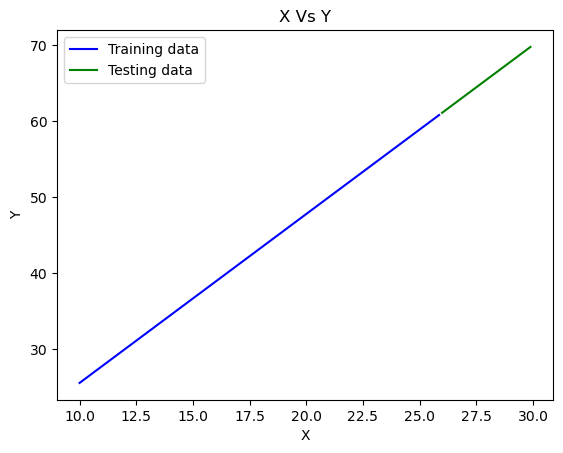

In [128]:
plot_data(X_train,y_train,X_test,y_test)

In [129]:

from torch import nn 

class MyFirstNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.weights*x + self.bias 
    
    

In [130]:
torch.manual_seed(42)
model1 = MyFirstNeuralNetwork()
model1.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

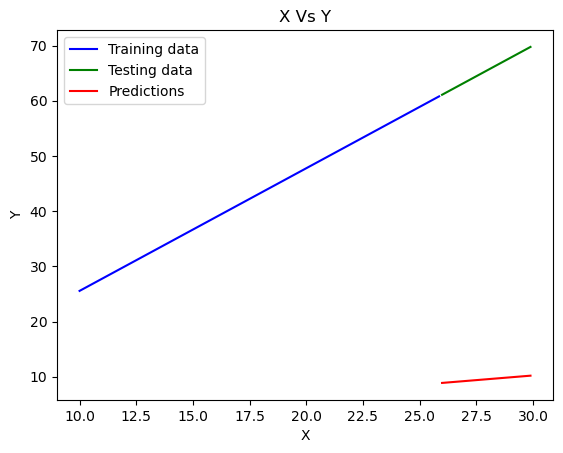

In [131]:
#predict before training 
with torch.inference_mode():
    y_pred = model1(X_test)
plot_data(X_train, y_train, X_test, y_test, predictions=y_pred)

In [132]:
# loss function 
loss_fn = nn.MSELoss()
# adam optimizer
optimizer = torch.optim.Adam(
    params = model1.parameters(),
    lr = 0.01
)

In [133]:
# training loop 
epochs = 200
train_loss_list = []
test_loss_list = []

for epoch in range(epochs):
    # training mode
    model1.train()

    # get predictions on the training data
    train_preds = model1(X_train)

    # compute training loss
    loss = loss_fn(y_train, train_preds)

    # zero grad the optimizer
    optimizer.zero_grad()

    # backpropagate
    loss.backward()

    # step the optimizer
    optimizer.step()

    # testing mode
    model1.eval()
    with torch.inference_mode():
        # get the test preds
        test_preds = model1(X_test)

        # compute the test loss using the current epoch predictions
        test_loss = loss_fn(y_test, test_preds)

    train_loss_list.append(loss.item())
    test_loss_list.append(test_loss.item())

    if epoch % 10 == 0:
        print(f"Epochs {epoch + 1} | Train loss {loss:.6f} | Test loss {test_loss:.6f}")

Epochs 1 | Train loss 1445.304932 | Test loss 3095.044189
Epochs 11 | Train loss 1301.198364 | Test loss 2781.862061
Epochs 21 | Train loss 1165.915894 | Test loss 2488.358398
Epochs 31 | Train loss 1040.221436 | Test loss 2216.090332
Epochs 41 | Train loss 924.407166 | Test loss 1965.587524
Epochs 51 | Train loss 818.387451 | Test loss 1736.583008
Epochs 61 | Train loss 721.836792 | Test loss 1528.312134
Epochs 71 | Train loss 634.301086 | Test loss 1339.748657
Epochs 81 | Train loss 555.266479 | Test loss 1169.746460
Epochs 91 | Train loss 484.195251 | Test loss 1017.112915
Epochs 101 | Train loss 420.545074 | Test loss 880.648560
Epochs 111 | Train loss 363.778381 | Test loss 759.165894
Epochs 121 | Train loss 313.366608 | Test loss 651.499451
Epochs 131 | Train loss 268.795105 | Test loss 556.514526
Epochs 141 | Train loss 229.564423 | Test loss 473.111755
Epochs 151 | Train loss 195.194550 | Test loss 400.235321
Epochs 161 | Train loss 165.225677 | Test loss 336.874481
Epochs 171 

In [134]:
print(train_loss_list[0], train_loss_list[-1])
print(test_loss_list[0], test_loss_list[-1])

1445.304931640625 82.52123260498047
3095.044189453125 163.4119415283203


In [135]:
print(model1.state_dict())

OrderedDict([('weights', tensor([1.8261])), ('bias', tensor([1.6198]))])


In [136]:
w2 = 2.3836
b2 = 0.2436

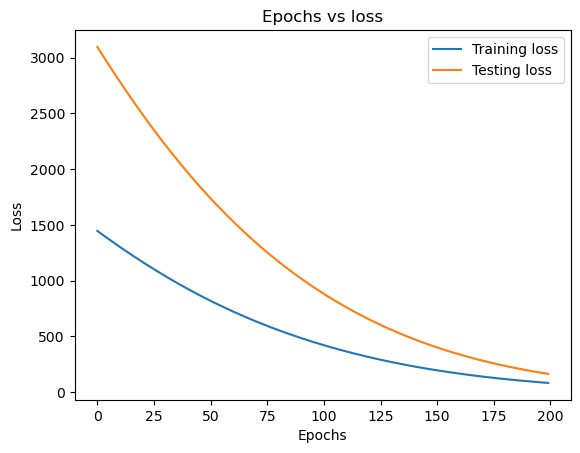

In [137]:
epochs = len(train_loss_list)
plt.plot(range(epochs), train_loss_list, label="Training loss")
plt.plot(range(epochs),test_loss_list,label="Testing loss")
plt.title("Epochs vs loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("0.5lr.png",dpi=300,bbox_inches="tight")
plt.show()

### comparison among two learning procedures

In [138]:
print(f"The differences between weights and bias obtained for same data using two different methods are: \n w={abs(w-w2):.3f} and b={abs(b-b2):.3f}")

The differences between weights and bias obtained for same data using two different methods are: 
 w=1.940 and b=0.474
